# FRB cosmology constrain from $DM_{IGM} $

Highly uncertain: $\Omega_b, f_{IGM}, \chi, \omega$ (If do wCDM cosmology)

For FRB, cosmology distance is based on the dispersion measure (DM), which defined as
$$ DM=\int_0^{D_z}\frac{n_e(l)}{1+z(l)}dl $$

DM can be splitted into multiple terms:
$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$
where $DM_{MW}$ is the DM from the Milky Way, $DM_{halo}$ is the DM from the halo, $DM_{IGM}$ is the DM from the intergalactic medium, $DM_{host}$ is the DM from the host galaxy, and $DM_{src}$ is the DM from the source.

$DM_{MW}$ can be derived from model. $DM_{halo} \sim (30-80)pc \; cm^{-3}$

Most important is the IGM component:
$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\Chi(z')(1+z')dz'}{E(z')}$$
Here,
$$\Chi=Y_H X_{e,H}+\frac{1}{2}Y_{He} X_{e,He}$$
Recall $Y_H=1/4$ and $Y_{He}=3/4$.

According to [[Bei Zhou 2014](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.89.107303)], $z\lesssim 3$, $X_{e,H}=X_{e,He}=1$; at $z\gtrsim 1.5$ $f_{IGM}\approx 90\%$; as $z\leq 0.4$ $f_{IGM}\approx (82\pm 4)\%$

H fully ionized ($\chi_{e,H}=1)$ at $ z<6 $ ([Fan 2006](https://www.annualreviews.org/content/journals/10.1146/annurev.astro.44.051905.092514)), He fully ionized ($\chi_{e,He}=1$) at $ z<2$ ([McQuinn 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...694..842M/abstract))

In [1]:
import sys
sys.path.append('../Python_scripts')
from config import *
from support import *
from cosmo_support import *

In [ ]:
# From DM derive redshift. Previous project analyze code.
# from scipy import integrate

# def f_IGM(z):
#     #0.84
#     return (z>1.5)*0.9+(z<=1.5)*(0.053*z+0.82) #0.83 #according to Bei Zhou 2014 paper

# def I_IGM(z,m=O_m,la=O_L):
#     return (1.+z)*f_IGM(z)/np.sqrt(m*(1.+z)**3+la)

# def f_DM(z,a=alpha):
#     Int=integrate.quad(I_IGM,0,z)[0]
#     return 30.0+a*Int+70.0/(1.+z)

# from scipy.optimize import fsolve
# def f_z(DM_MW,n=8):
#     ''' z1=0
#     z2=3
#     E=z2-z1
#     error=1/pow(10,n)
#     while E>=error/2:
#         #print([f_DM(z1),f_DM(z2)])
#         zt=(z1+z2)/2
#         ft=f_DM(zt)-DM_MW
        
#         if(ft<0):
#             z1=zt
#         elif(ft>0):
#             z2=zt
#         else:
#             z=zt
#             break
        
#         E=z2-z1
#         z=round((z1+z2)/2,n)
#         #if(z==0):
#         #    z=0.01 '''
#     return fsolve(lambda z:f_DM(z)-DM_MW,0)[0]

# load the FRB data

In [2]:
df1 = pd.read_csv('FRB_Surajit.csv')
df1['DM_ext']=df1['DM_obs (pc cm^-3)']-df1['DM_MW (pc cm^-3)']
df1.head()

,FRB,DM_obs (pc cm^-3),E_DM_obs,DM_MW (pc cm^-3),z,DM_ext
0,FRB 20121102A,557.00,2.00,188.0,0.19273,369.00
1,FRB 20171020A,114.10,0.20,38.0,0.00860,76.10
2,FRB 20180301A,522.00,0.20,152.0,0.33040,370.00
3,FRB 20180916B,349.30,0.20,200.0,0.03370,149.30
4,FRB 20180924B,361.42,0.06,40.5,0.32140,320.92


In [5]:
df2 = pd.read_excel('FRB_Kritti.xlsx')
df2['FRB']='FRB '+df2['FRB']
df2.head()

,FRB,RA,Decl,z,E_z,DM_ext
0,FRB 20220319D,02:08:42.70,+71:02:06.94,0.0112,0.0001,-22
1,FRB 20231120A,09:35:56.15,+73:17:04.80,0.0368,0.0001,395
2,FRB 20220207C,20:40:47.89,+72:52:56.38,0.0433,0.0001,182
3,FRB 20220509G,18:50:40.80,+70:14:37.80,0.0894,0.0001,214
4,FRB 20230124A,15:27:39.9,+70:58:05.20,0.0939,0.0002,551


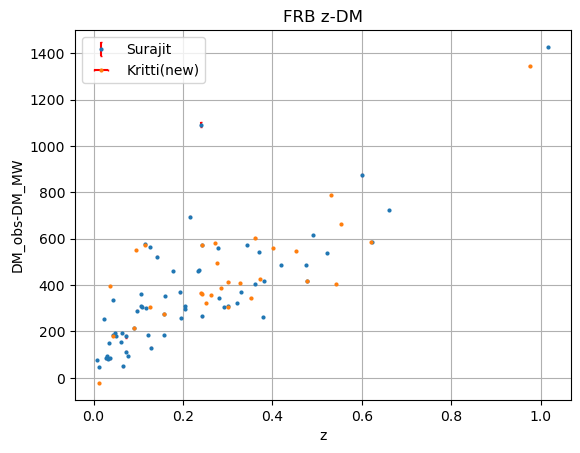

In [7]:
plt.errorbar(df1['z'], df1['DM_ext'], yerr=df1['E_DM_obs'], fmt='o', ecolor='red', capsize=1, label='Surajit',markersize=2)
plt.errorbar(df2['z'], df2['DM_ext'], xerr=df2['E_z'], fmt='o', ecolor='red', capsize=1, label='Kritti(new)',markersize=2)
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.legend()
plt.grid(True)
plt.show()

combine data sets

df1 have E_DM, df2 have E_z

In [9]:
data=df1[['FRB','DM_ext','z']]
data=pd.concat([data,df2[['FRB','DM_ext','z']]],ignore_index=True)
data.head()

,FRB,DM_ext,z
0,FRB 20121102A,369.00,0.19273
1,FRB 20171020A,76.10,0.00860
2,FRB 20180301A,370.00,0.33040
3,FRB 20180916B,149.30,0.03370
4,FRB 20180924B,320.92,0.32140


## Normal distribution, the simplest case

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm host}$ and potentially the source itself ${\rm DM}_{\rm host}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm host} \sim 30,
$$

$$
\sigma_{\rm DM_{IGM}} = \sqrt{\sigma_{\rm obs}^2+\sigma_{\rm MW}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm host}}{1+z}\right)^2},
$$

consider uncertainty in Jun-jie Wei's paper first:

In [22]:
def sigma_DM_IGM(z, sigma_obs=1.5, sigma_MW=10, sigma_IGM=100, sigma_host=30):
    a=sigma_obs**2+sigma_MW**2+sigma_IGM**2+(sigma_host/(1+z))**2
    return np.sqrt(a)

F_fid=HUBBLE*OMEGA_BARYONS*f_IGM
print(F_fid)

2.818431


In [16]:
def DM_IGM(z, F, Om=OMEGA_MATTER, w=-1):   

    factor = 3*C_LIGHT*KM_2_MPC*F/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [19]:
F_array=np.linspace(1.0,10,1000)
Chi=np.zeros_like(F_array)
sigma_vec=np.vectorize(sigma_DM_IGM)
DM_vec=np.vectorize(DM_IGM)

for idx, F in enumerate(F_array):
    DM_th=DM_vec(data['z'],F)
    sigma=sigma_vec(data['z'])
    Chi[idx]=np.sum((data['DM_ext']-DM_th)**2/sigma**2)

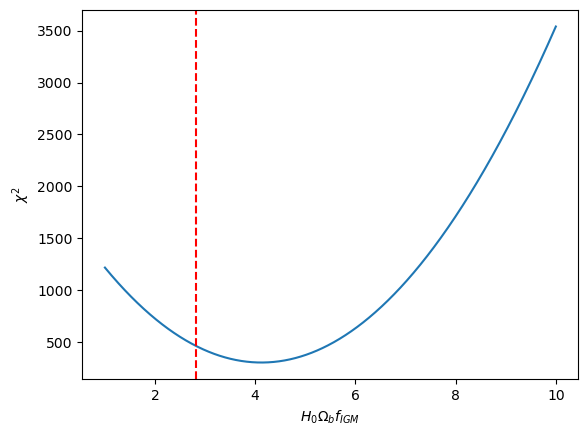

In [27]:
plt.plot(F_array, Chi)
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'$\chi^2$')
plt.show()